In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('global_ecommerce_sales.csv', encoding='latin1')
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [ ]:
#Limpeza e Padronização dos Dados
# Converte datas
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Verificar nulos 
print(df.isnull().sum())

# Cria colunas de tempo para facilitar no Matplotlib
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Quarter'] = df['Order_Date'].dt.quarter
df['Day_of_Week'] = df['Order_Date'].dt.day_name() 
df['Month_Year'] = df['Order_Date'].dt.to_period('M')

# Métricas Financeiras
df['Profit_Margin'] = (df['Profit'] / df['Total_Sales']) * 100

# Categorização de Lucro (Para usar cores nos graficos)
df['Is_Profitable'] = df['Profit'] > 0

# Faixas de Desconto 
bins = [-1, 0, 10, 20, 30, 100]
labels = ['Sem Desconto', '1-10%', '11-20%', '21-30%', '30%+']
df['Discount_Range'] = pd.cut(df['Discount_Percent'], bins=bins, labels=labels)

# Cria coluna de Margem de Lucro (%)
df['Profit_Margin'] = (df['Profit'] / df['Total_Sales']) * 100

Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64


In [ ]:
#  Extração de Informações

# Pergunta 1 Sazonalidade das vendas 
# Agrupando vendas por mês/ano 
sazonalidade = df.groupby('Month_Year')['Total_Sales'].sum().reset_index()

# Pergunta 2 Rentabilidade por Categoria 
# Verificando qual categoria deixa mais dinheiro no bolso
rentabilidade_cat = df.groupby('Product_Category')[['Total_Sales', 'Profit', 'Profit_Margin']].mean().sort_values(by='Profit', ascending=False)

# Pergunta 3 Impacto do Custo de Frete na Rentabilidade por Região
# onde o frete é mais caro e consome o lucro?
logistica_regiao = df.groupby('Region').agg({
    'Shipping_Cost': 'mean',
    'Profit': 'mean',
    'Total_Sales': 'sum'
}).sort_values(by='Shipping_Cost', ascending=False)

# Pergunta 4 Geografia do Lucro (Onde estamos perdendo dinheiro?)
# Agrupando por país para identificar operações com deficit
lucro_geografico = df.groupby('Country').agg({
    'Profit': 'sum',
    'Total_Sales': 'sum'
}).sort_values(by='Profit')

# Pergunta 5 Fidelização (LTV - Valor do Tempo de Vida do Cliente) 
# Identificando os clientes que mais compram 
top_clientes = df.groupby('Customer_Name').agg({
    'Order_ID': 'count', 
    'Total_Sales': 'sum'
}).rename(columns={'Order_ID': 'Total_Orders'}).sort_values(by='Total_Sales', ascending=False)

# Pergunta 6 Impacto de Descontos
# Analisando se desconto alto = prejuízo
impacto_desconto = df.groupby('Discount_Percent')[['Profit', 'Total_Sales']].mean().reset_index()

# Pergunta 7 Análise de Ticket Médio por Segmento
# Ajuda a entender qual perfil de cliente gasta mais por pedido
ticket_medio_segmento = df.groupby('Customer_Segment').agg({
    'Total_Sales': 'mean',
    'Profit': 'mean'
}).rename(columns={'Total_Sales': 'Average_Ticket'}).sort_values(by='Average_Ticket', ascending=False)

# Pergunta 8 Produtos "Estrela" vs "prejuízo"
# Identifica os 10 produtos que mais dão lucro e os 10 que mais dão prejuízo
produtos_performance = df.groupby('Product_Name').agg({
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values(by='Profit', ascending=False)
top_10_estrelas = produtos_performance.head(10)
top_10_cachorros = produtos_performance.tail(10)

# Pergunta 9 Preferência de Métodos de Pagamento por Região
# Útil para entender infraestrutura financeira local e taxas
pagamento_regiao = pd.crosstab(df['Region'], df['Payment_Method'], normalize='index') * 100

# Pergunta 10 Previsão de Demanda (Tendência de crescimento por Categoria)
# Vamos ver como cada categoria evoluiu mês a mês
tendencia_categoria = df.groupby(['Month_Year', 'Product_Category'])['Total_Sales'].sum().unstack().fillna(0)


In [ ]:
# Exportação do Dataset
df.to_csv('global_ecommerce_sales_cleaned.csv', index=False)
print("Dataset limpo e colunas extras criadas com sucesso!")

Dataset limpo e colunas extras criadas com sucesso!


In [ ]:
# importação da biblioteca matplotlib para criar gráficos
import matplotlib.pyplot as plt

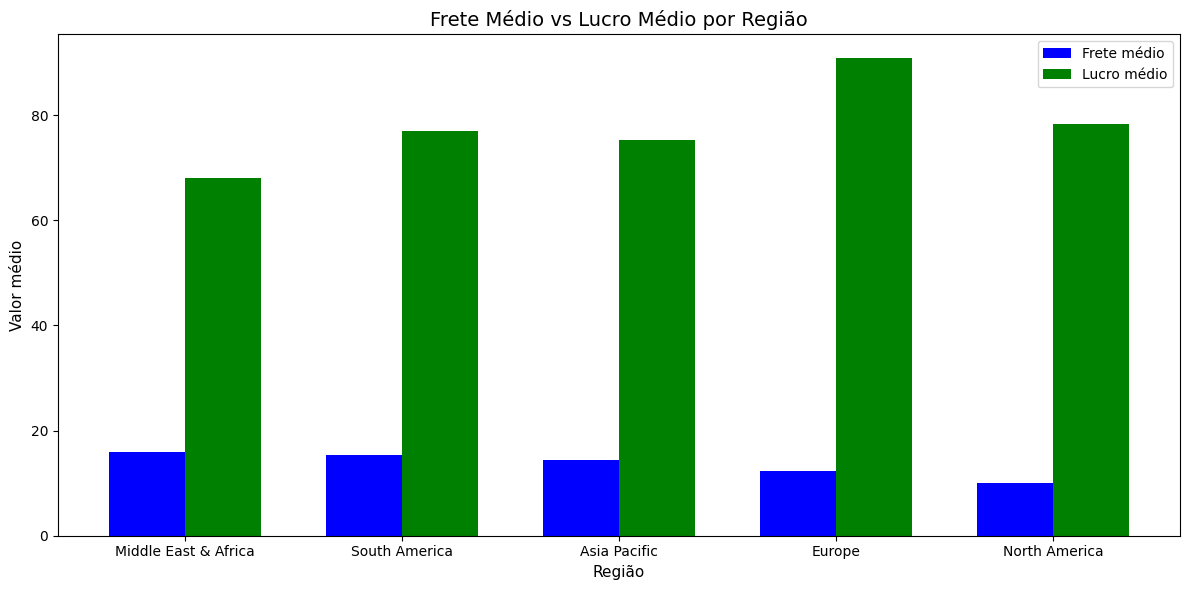

In [ ]:
# gráfico de barras duplas: frete médio vs lucro médio por região

# o objetivo é comparar o custo de frete médio com o lucro médio para cada região, para identificar se há regiões onde o frete consome uma parte significativa do lucro.

# copiamos o dataframe para não alterar o original
dados = logistica_regiao.copy()

# aumenta o tamanho do gráfico para dar mais espaço aos nomes das regiões
plt.figure(figsize=(12, 6))

# pegamos nomes das regiões para usar no eixo x
regioes = dados.index
# criamos uma sequência numérica para posicionar as barras de cada região
x = np.arange(len(regioes))
largura = 0.35

# criamos as barras para frete médio e lucro médio, posicionando-as lado a lado
plt.bar(x - largura/2, dados["Shipping_Cost"], largura, label="Frete médio", color="blue")
plt.bar(x + largura/2, dados["Profit"], largura, label="Lucro médio", color="green")

# adicionamos título e rótulos aos eixos
plt.title("Frete Médio vs Lucro Médio por Região")
plt.xlabel("Região")
plt.ylabel("Valor médio")

# função para mostrar os nomes das regiões no eixo x, se não apareceriam números
plt.xticks(x, regioes, rotation=45, ha="right")

# adicionamos a legenda, ajustamos o layout e exibimos o gráfico
plt.legend()
plt.tight_layout()
plt.show()

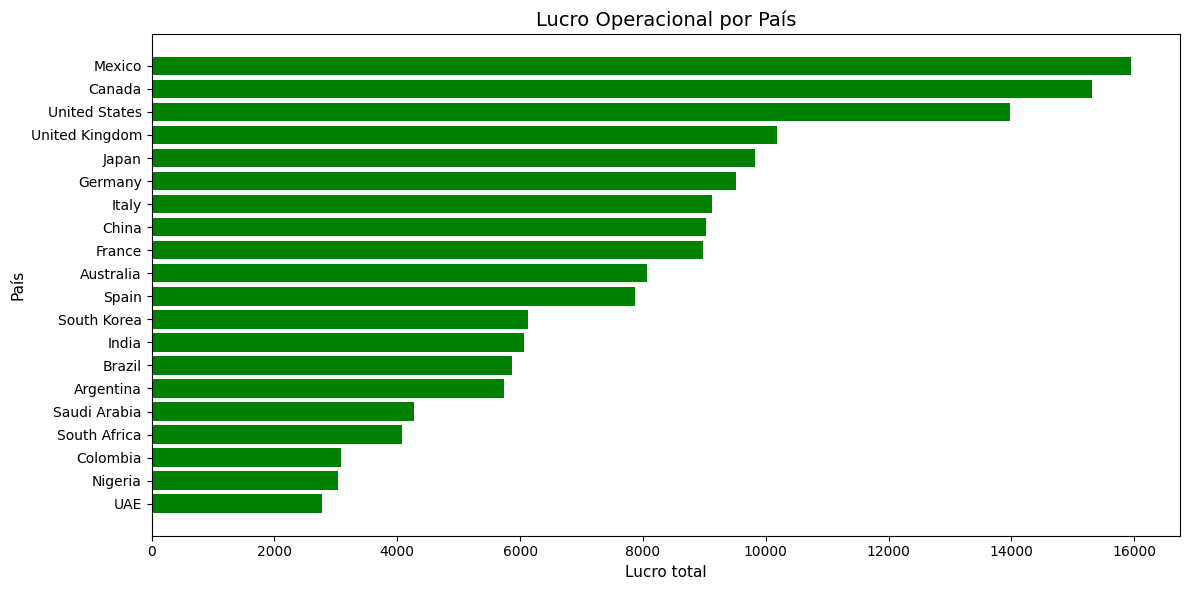

In [ ]:
# gráfico de barras horizontal: lucro por país

# o objetivo é identificar quais países estão gerando lucro e quais estão gerando prejuízo, para direcionar estratégias de mercado ou logística.

# copiamos o dataframe para não alterar o original
dados = lucro_geografico.copy()

# criamos uma lista de cores para as barras, onde vermelho indica prejuízo e verde indica lucro
cores = []

# iteramos sobre os valores de lucro para determinar a cor de cada barra
for valor in dados["Profit"]:
    if valor < 0:
        cores.append("red")
    else:
        cores.append("green")

# criamos o gráfico de barras horizontal, usando as cores definidas
plt.barh(dados.index, dados["Profit"], color=cores)

# adicionamos título e rótulos aos eixos
plt.title("Lucro Operacional por País")
plt.xlabel("Lucro total")
plt.ylabel("País")

# ajustamos o layout e exibimos o gráfico
plt.tight_layout()
plt.show()

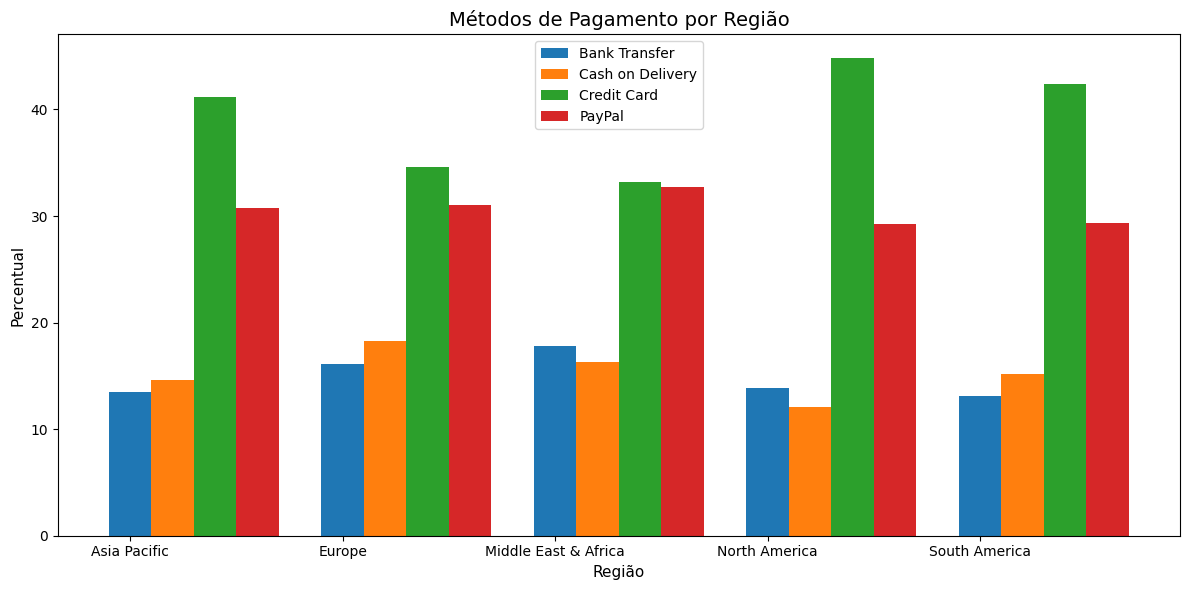

In [ ]:
# gráfico de barras duplas: métodos de pagamento por região

# o objetivo é comparar a preferência por métodos de pagamento em cada região, para entender melhor o comportamento do consumidor e possíveis barreiras de pagamento.

# copiamos o dataframe para não alterar o original
dados = pagamento_regiao.copy()

# aumenta o tamanho do gráfico para melhorar a visualização
plt.figure(figsize=(12, 6))

# pegamos os nomes das regiões e dos métodos de pagamento para usar no gráfico
regioes = dados.index
metodos = dados.columns

# criamos uma sequência numérica para posicionar as barras de cada região
x = np.arange(len(regioes))
largura = 0.2

# iteramos sobre os métodos de pagamento para criar as barras de cada um, posicionando-as lado a lado
for i in range(len(metodos)):
    plt.bar(
        x + i * largura,
        dados[metodos[i]],
        largura,
        label=metodos[i]
    )

# adicionamos título e rótulos aos eixos
plt.title("Métodos de Pagamento por Região")
plt.xlabel("Região")
plt.ylabel("Percentual")

# função para colocar os nomes das regiões no eixo x
plt.xticks(x, regioes)

# adicionamos a legenda, ajustamos o layout e exibimos o gráfico
plt.legend()
plt.tight_layout()
plt.show()

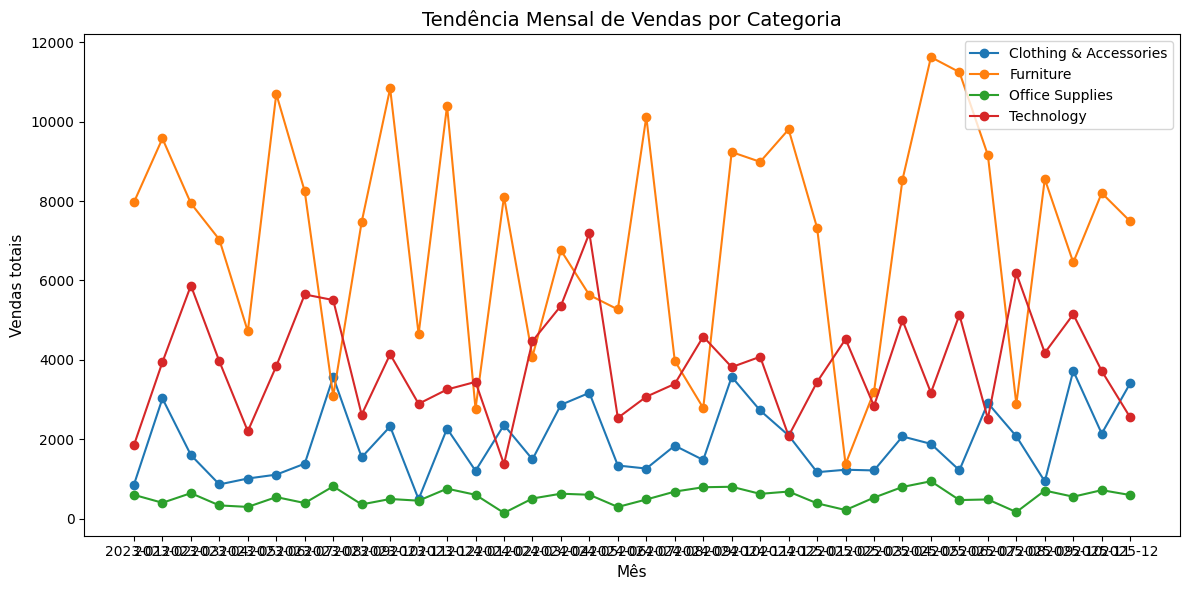

In [ ]:
# gráfico de linhas: tendência de vendas por categoria

# o objetivo é visualizar como as vendas de cada categoria evoluíram ao longo do tempo, para identificar tendências sazonais ou de crescimento.

# copiamos o dataframe para não alterar o original
dados = tendencia_categoria.copy()

# transforma o índice em texto para aparecer no eixo X
meses = dados.index.astype(str)

# cria posições numéricas para cada mês
x = np.arange(len(meses))

# aumenta o tamanho do gráfico para melhorar a leitura
plt.figure(figsize=(14, 6))

# cria uma linha para cada categoria
for categoria in dados.columns:
    plt.plot(
        x,
        dados[categoria],
        marker="o",
        label=categoria
    )

plt.title("Tendência Mensal de Vendas por Categoria")
plt.xlabel("Mês")
plt.ylabel("Vendas totais")

# Mostra apenas alguns meses no eixo X para não ficar tudo sobreposto
# O valor 3 significa que será mostrado um rótulo a cada 3 meses
intervalo = 3
plt.xticks(x[::intervalo], meses[::intervalo], rotation=45)

plt.legend()
plt.tight_layout()
plt.show()